# Bitcoin Market Sentiment and Trader Performance Analysis

## Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The goal is to identify how trader profitability changes under different market sentiment regimes and derive actionable insights that can support smarter trading strategies.


# 1. Import Libraries

The required Python libraries are imported for data manipulation, analysis, and visualization.


In [35]:
from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data (1).csv


In [37]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv


# 2. Data Loading

The Bitcoin Fear & Greed dataset and Hyperliquid trading dataset are loaded into Pandas DataFrames for analysis.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional but useful
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# 3. Initial Data Exploration

The datasets are inspected to understand their structure, dimensions, and available features.

In [40]:
import os

print(os.listdir())

['.config', 'historical_data (1).csv', 'fear_greed_index (1).csv', 'fear_greed_index.csv', 'historical_data.csv', 'sample_data']


In [41]:
print(trader_df.head())
print(trader_df.shape)
print(trader_df.columns) # Trader Data

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

# 4. Data Quality Assessment

Data types, missing values, and dataset consistency are examined before further processing.

In [42]:
print(sentiment_df.head())
print(sentiment_df.shape)
print(sentiment_df.columns)
sentiment_df.info()

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
(2644, 4)
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [43]:
trader_df.info()
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [44]:
trader_df.isnull().sum()
sentiment_df.isnull().sum()


,0
timestamp,0
value,0
classification,0
date,0


# 5. Data Cleaning and Date Standardization

Trade timestamps and sentiment dates are converted into a common format to enable accurate merging of both datasets.

In [45]:
print(trader_df.columns)
print(sentiment_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [46]:
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    dayfirst=True
)

trader_df['Date'] = trader_df['Timestamp IST'].dt.date

# 6. Data Integration

The trading dataset is merged with the Fear & Greed Index dataset using the trading date.

This allows each trade to be associated with the prevailing market sentiment on the day it occurred.

In [47]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df['Date'] = sentiment_df['date'].dt.date
merged_df = trader_df.merge(
    sentiment_df[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)
merged_df[['Date', 'classification', 'Closed PnL']].head()

,Date,classification,Closed PnL
0,2024-12-02,Extreme Greed,0.0
1,2024-12-02,Extreme Greed,0.0
2,2024-12-02,Extreme Greed,0.0
3,2024-12-02,Extreme Greed,0.0
4,2024-12-02,Extreme Greed,0.0


## Verification

The output confirms that each trade has been successfully matched with the corresponding market sentiment classification based on its trading date.

This enables sentiment-specific performance analysis in the following sections.

## Handling Missing Sentiment Values

After merging the trading and sentiment datasets, a small number of records contained missing sentiment classifications.

These records were removed to ensure that all subsequent analyses are based on trades with valid market sentiment information.

In [48]:
merged_df['classification'].isnull().sum()


np.int64(6)

In [49]:
merged_df = merged_df.dropna(subset=['classification'])
merged_df['classification'].isnull().sum()

np.int64(0)

### Result

The output confirms that all missing sentiment classifications were successfully removed from the merged dataset, ensuring data consistency for further analysis.

# 7. Sentiment-Based Profitability Analysis

This section investigates how trader profitability varies across different Bitcoin market sentiment conditions.

The analysis calculates the number of trades, average profit per trade, and total profit generated under each sentiment category (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed).

In [50]:
sentiment_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count', 'mean', 'sum']
)

print(sentiment_pnl)

                count       mean           sum
classification                                
Extreme Fear    21400  34.537862  7.391102e+05
Extreme Greed   39992  67.892861  2.715171e+06
Fear            61837  54.290400  3.357155e+06
Greed           50303  42.743559  2.150129e+06
Neutral         37686  34.307718  1.292921e+06


## Key Finding

Extreme Greed recorded the highest average profit per trade (67.89), while Fear generated the highest total profit across all trades.

These results indicate that trader performance is influenced by market sentiment, with different sentiment regimes creating distinct profit opportunities.

## Visualization: Average Profit by Market Sentiment

The following chart compares the average profit per trade across different market sentiment categories.

This visualization helps identify which market conditions are associated with the highest trader profitability.


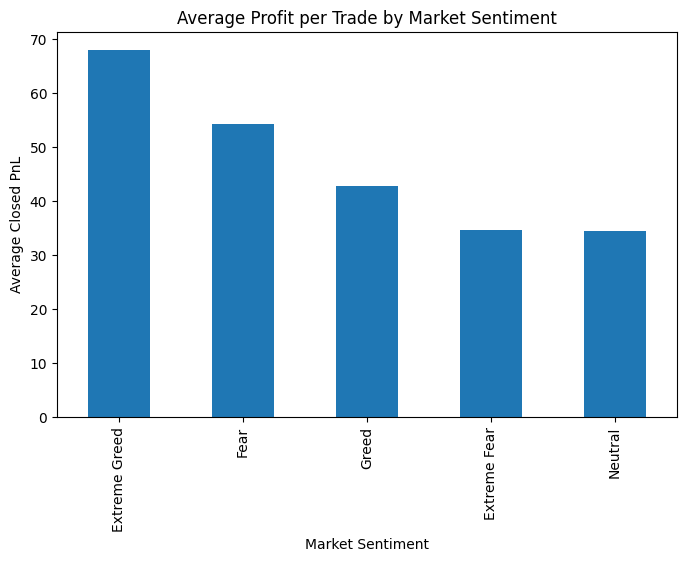

In [51]:
import matplotlib.pyplot as plt

avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(8,5))
avg_pnl.sort_values(ascending=False).plot(kind='bar')

plt.title('Average Profit per Trade by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Market Sentiment')

plt.show()

### Interpretation

The chart shows that Extreme Greed generated the highest average profit per trade, followed by Fear.

In contrast, Neutral and Extreme Fear conditions produced lower average profitability. This suggests that trader performance is influenced by prevailing market sentiment and that different sentiment regimes create different trading opportunities.

# 8. Buy vs Sell Analysis

This section compares the profitability of BUY and SELL trades across different market sentiment conditions.

By analyzing average profit per trade for each trade direction, we can identify whether traders perform better when buying or selling under specific market regimes.

In [52]:
buy_sell_sentiment = merged_df.pivot_table(
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

print(buy_sell_sentiment)

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Extreme Greed   10.498927  114.584643
Fear            63.927104   45.049641
Greed           25.002302   59.691091
Neutral         29.227429   39.456408


## Key Finding

BUY trades achieved their highest profitability during Fear periods, with an average profit of 63.93 per trade.

SELL trades significantly outperformed BUY trades during Greed and Extreme Greed conditions, reaching an average profit of 114.58 during Extreme Greed.

These results suggest that traders may benefit from buying during fearful market conditions and taking profits or selling when market optimism becomes excessive.

## Visualization: BUY vs SELL Performance by Market Sentiment

The following chart compares the average profit per trade for BUY and SELL positions across different market sentiment categories.

This visualization helps identify which trade direction performs better under varying market conditions.

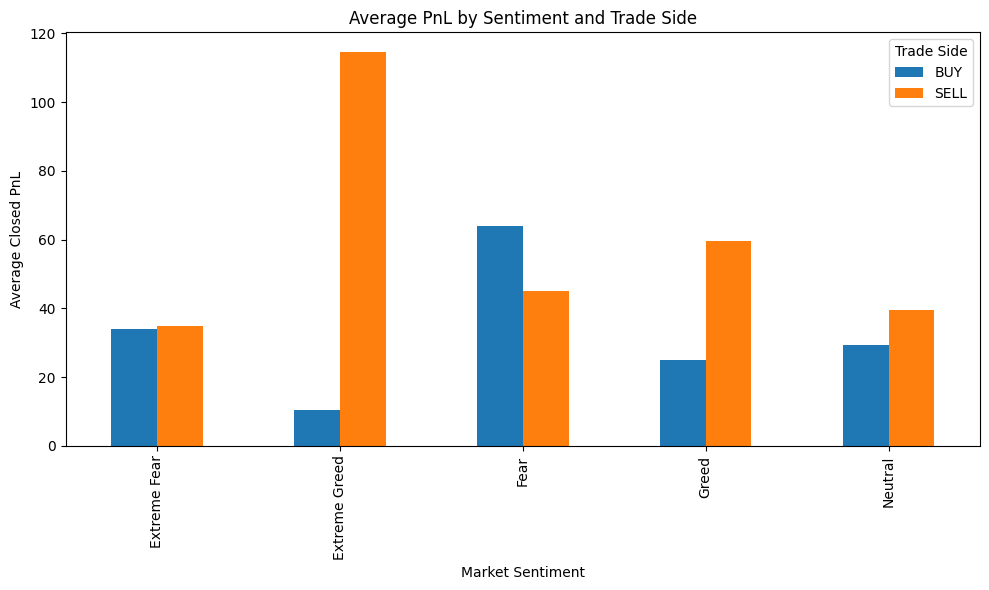

In [53]:
import matplotlib.pyplot as plt

buy_sell_sentiment.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average PnL by Sentiment and Trade Side')
plt.ylabel('Average Closed PnL')
plt.xlabel('Market Sentiment')
plt.legend(title='Trade Side')

plt.tight_layout()
plt.show()

### Interpretation

The chart reveals clear differences in profitability between BUY and SELL trades across market sentiment regimes.

BUY trades achieved their highest average profitability during Fear periods, indicating that traders may benefit from buying during market uncertainty and price declines.

SELL trades significantly outperformed BUY trades during Greed and Extreme Greed conditions. The highest average profit was observed for SELL trades during Extreme Greed, suggesting that profit-taking or contrarian strategies become particularly effective when market optimism reaches extreme levels.

These findings highlight the importance of adapting trading strategies based on prevailing market sentiment.

# 9. Trade Count Validation

Before drawing conclusions from the profitability analysis, it is important to verify that the observed patterns are supported by a sufficiently large number of trades.

This section examines the distribution of BUY and SELL trades across different market sentiment categories.

In [54]:
trade_counts = pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

print(trade_counts)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


## Key Finding

The number of BUY and SELL trades is relatively balanced across all sentiment categories.

For example, Extreme Greed contains 17,940 BUY trades and 22,052 SELL trades, while Fear contains over 30,000 trades for both directions.

The large sample sizes increase confidence that the profitability differences observed in the previous section are statistically meaningful rather than the result of a small number of trades.

## Visualization: Trade Distribution by Sentiment

The following chart shows the number of BUY and SELL trades executed under each market sentiment condition.

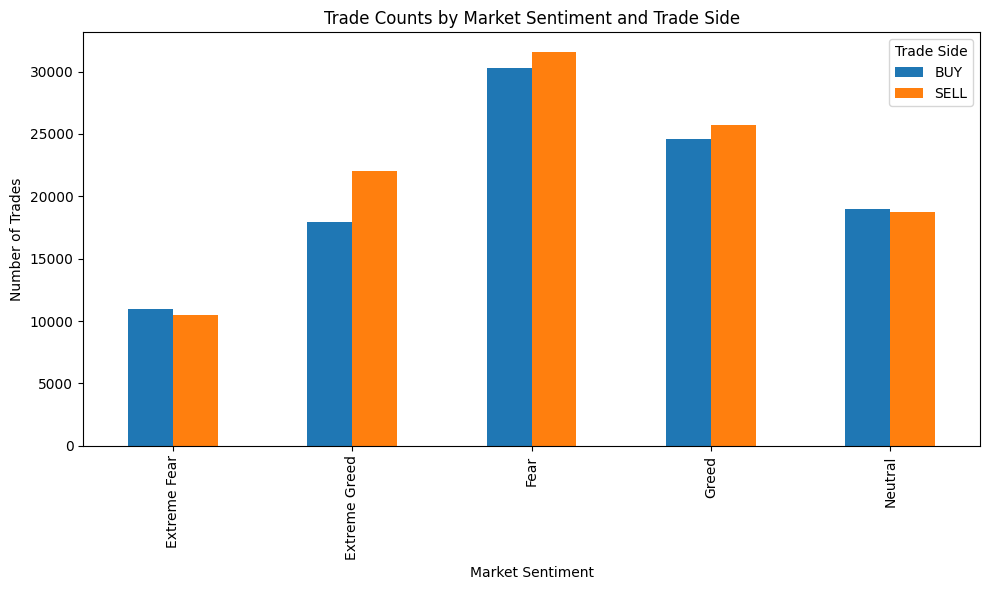

In [55]:
trade_counts.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Trade Counts by Market Sentiment and Trade Side')
plt.ylabel('Number of Trades')
plt.xlabel('Market Sentiment')
plt.legend(title='Trade Side')

plt.tight_layout()
plt.show()

### Interpretation

The chart confirms that trading activity is well distributed across both BUY and SELL directions.

Since the sample sizes are large and relatively balanced, the profitability patterns identified earlier are supported by a robust dataset and can be interpreted with greater confidence.

# 10. Coin-Level Analysis

This section examines profitability across different cryptocurrencies traded on the platform.

For each asset, the total number of trades, average profit per trade, and cumulative profit are calculated to identify the most profitable trading opportunities.

In [56]:
coin_pnl = merged_df.groupby('Coin')['Closed PnL'].agg(
    ['count', 'mean', 'sum']
)

coin_pnl = coin_pnl.sort_values(
    by='sum',
    ascending=False
)

print(coin_pnl.head(10))

         count        mean           sum
Coin                                    
@107     29992   92.821850  2.783913e+06
HYPE     68005   28.652079  1.948485e+06
SOL      10691  153.358519  1.639556e+06
ETH      11158  118.298874  1.319979e+06
BTC      26064   33.304356  8.680447e+05
MELANIA   4428   88.155165  3.903511e+05
ENA        990  219.524751  2.173295e+05
SUI       1979  100.691680  1.992688e+05
ZRO       1239  148.327509  1.837778e+05
DOGE       826  178.623676  1.475432e+05


## Key Finding

The asset @107 generated the highest cumulative profit, exceeding 2.7 million in total realized profit.

HYPE, SOL, ETH, and BTC also contributed significantly to overall profitability. While HYPE recorded a large total profit due to its high trading volume, assets such as SOL and ETH achieved substantially higher average profit per trade, indicating greater trading efficiency.

These findings suggest that profitability is not solely driven by trade frequency, but also by the effectiveness of trading opportunities within specific assets.

## Visualization: Top 10 Coins by Total Profit

The following chart ranks the ten most profitable cryptocurrencies based on cumulative realized profit.

This visualization helps identify which assets contributed the most to overall trader profitability.

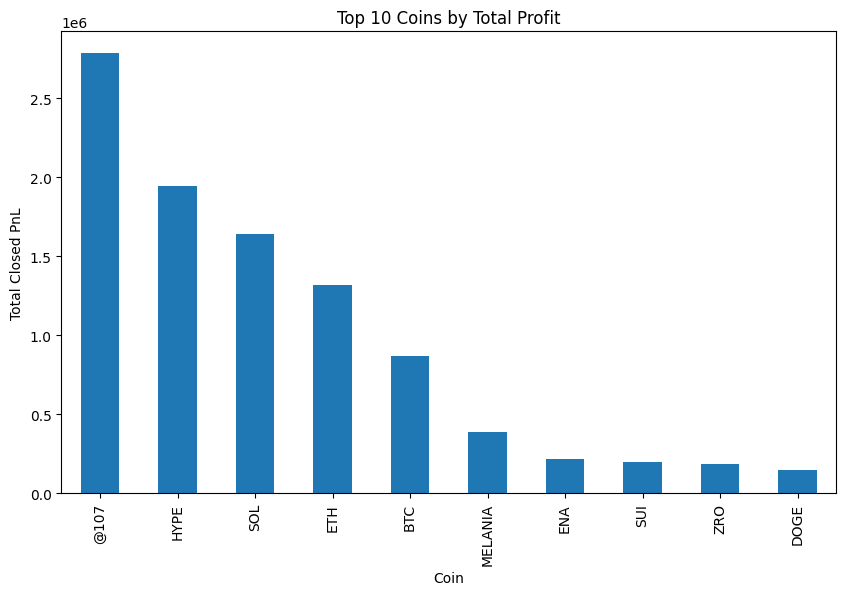

In [57]:
top10 = coin_pnl.head(10)

plt.figure(figsize=(10,6))
top10['sum'].plot(kind='bar')

plt.title('Top 10 Coins by Total Profit')
plt.ylabel('Total Closed PnL')
plt.xlabel('Coin')

plt.show()

### Interpretation

The chart shows that profitability is concentrated among a small number of assets.

The asset @107 generated the highest cumulative profit, followed by HYPE, SOL, ETH, and BTC. While HYPE benefited from a large trading volume, assets such as SOL and ETH delivered strong profitability with fewer trades, indicating greater efficiency on a per-trade basis.

These findings suggest that asset selection plays an important role in trading performance and profitability.

# 11. Trader-Level Analysis

This section identifies the most profitable traders in the dataset by analyzing the number of trades executed, average profit per trade, and cumulative profit.

The objective is to understand whether profitability is concentrated among a small number of traders and to explore different successful trading styles.

In [58]:
top_traders = merged_df.groupby('Account')['Closed PnL'].agg(
    ['count','mean','sum']
)

top_traders = top_traders.sort_values(
    by='sum',
    ascending=False
)

print(top_traders.head(10))

                                            count        mean           sum
Account                                                                    
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  14733  145.481748  2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012   3818  419.127768  1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864  21192   44.364091  9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1  12236   68.684419  8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  40184   20.806305  8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   4356  155.589314  6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   1590  270.034947  4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713   1237  336.735548  4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   9893   38.319560  3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   1424  253.187858  3.605395e+05


## Key Finding

The top-performing traders generated substantially higher profits than the average participant, indicating that profitability is concentrated among a relatively small group of accounts.

Different traders achieved success through different approaches. Some traders executed a large number of trades with moderate average profits, while others achieved exceptional average profits with a smaller number of trades.

This suggests that multiple trading styles can be profitable depending on market conditions and strategy execution.

## Performance of Top Traders Across Market Sentiment

To better understand how successful traders adapt to changing market conditions, the performance of the top five traders is analyzed across different sentiment regimes.

This analysis examines whether top traders consistently generate profits in all market conditions or specialize in specific sentiment environments such as Fear or Greed.

In [59]:
top5_accounts = (
    merged_df.groupby('Account')['Closed PnL']
    .sum()
    .nlargest(5)
    .index
)

top5_sentiment = merged_df[
    merged_df['Account'].isin(top5_accounts)
].groupby(
    ['Account','classification']
)['Closed PnL'].mean().unstack()

print(top5_sentiment)

classification                              Extreme Fear  Extreme Greed  \
Account                                                                   
0x083384f897ee0f19899168e3b1bec365f52a9012   1247.692214     -42.626810   
0x513b8629fe877bb581bf244e326a047b249c4ff1   -205.554395       0.000000   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     12.915976     672.735763   
0xbaaaf6571ab7d571043ff1e313a9609a10637864     58.463834            NaN   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab      6.059085      71.219912   

classification                                    Fear       Greed     Neutral  
Account                                                                         
0x083384f897ee0f19899168e3b1bec365f52a9012  626.194346  482.089321  298.456334  
0x513b8629fe877bb581bf244e326a047b249c4ff1   61.388767   51.450825  151.501984  
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   31.003381   90.687423  116.086038  
0xbaaaf6571ab7d571043ff1e313a9609a10637864   49.921394    0.934492   

## Visualization: Top 10 Traders by Total Profit

The following chart highlights the ten traders who generated the highest cumulative profits during the observation period.

By comparing total realized profits across traders, we can assess whether profitability is concentrated among a small number of accounts.

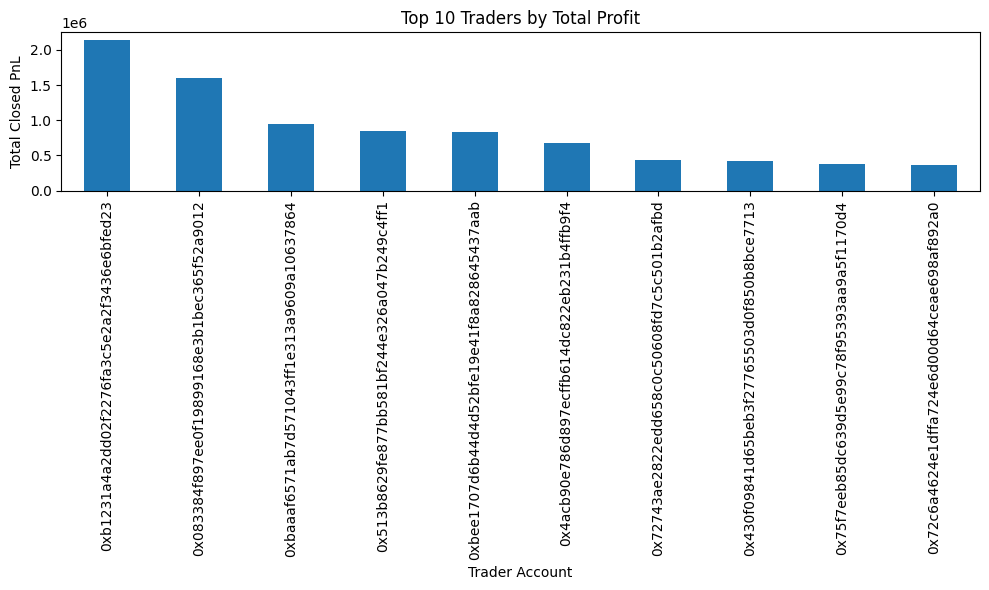

In [60]:
top10_traders = (
    merged_df.groupby('Account')['Closed PnL']
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10,6))
top10_traders.plot(kind='bar')

plt.title('Top 10 Traders by Total Profit')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')

plt.tight_layout()
plt.show()

### Interpretation

The chart shows that profitability is concentrated among a relatively small number of traders.

The most profitable trader generated more than 2 million in cumulative profit, while several other traders also achieved substantial returns. This indicates that trader performance varies significantly and that a small group of highly successful traders contributes a large share of total profits.

The findings suggest that trading skill, strategy selection, and risk management play an important role in determining long-term profitability.

# 12. Risk Analysis

This section examines the relationship between trade size and profitability.

A correlation analysis is performed to determine whether larger trading positions are associated with higher profits.

In [61]:
merged_df[['Size USD','Closed PnL']].corr()

,Size USD,Closed PnL
Size USD,1.000000,0.123645
Closed PnL,0.123645,1.000000


## Key Finding

The correlation between trade size (Size USD) and profitability (Closed PnL) is 0.124, indicating a weak positive relationship.

While larger trades tend to generate slightly higher profits, the relationship is not strong enough to suggest that position size alone drives profitability.

This finding implies that market conditions, trading strategy, and execution quality likely have a greater impact on trading performance than trade size.

# 13. Strategic Recommendations

### Recommendation 1
Adopt sentiment-aware trading strategies rather than using a single approach across all market conditions.

### Recommendation 2
Consider BUY-oriented strategies during Fear periods, where average profitability was highest.

### Recommendation 3
Consider profit-taking or SELL-oriented strategies during Greed and Extreme Greed periods, where SELL trades consistently outperformed BUY trades.

### Recommendation 4
Focus on assets with strong profitability characteristics, such as SOL and ETH, which demonstrated high average profit per trade.

### Recommendation 5
Recognize that successful traders perform differently across sentiment regimes, suggesting the importance of strategy diversification and adaptability.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data and the Bitcoin Fear & Greed Index.

The results demonstrate that market sentiment has a measurable impact on trading outcomes. Fear periods were associated with strong BUY-side profitability, while SELL trades generated the highest returns during Greed and Extreme Greed conditions.

Asset-level analysis revealed that profitability is concentrated among a small number of cryptocurrencies, while trader-level analysis showed that successful traders employ different strategies depending on market conditions.

Overall, the findings suggest that sentiment-aware trading strategies, adaptive decision-making, and effective asset selection can contribute significantly to improved trading performance.